## Preamble

In [1]:
import os
import numpy as np
#from scipy import signal
import matplotlib.pyplot as plt

nz=201; nx=201; h=10

fpeak=7; dt=0.0016; nt=2500

ntr=100

def read(filename,n=(nx,nz)):
    return np.fromfile(filename,dtype='float32').reshape(n).T

def read_su(filename,n=(ntr,nt)):
    data=read(filename,n=(n[0],int(60+n[1])))
    return data[60:,:]

# def read_snap(filename,n=(nsnap,nxsnap,nzsnap),i=26):
#     tmp=np.fromfile(filename,dtype='float32').reshape(n).T
#     return tmp[:,:,i]

def imshow(data,perc=None,clip=None,clipmin=None,extent=None,cmap='viridis',title=None,grid=True):
    
    if perc==None:
        clipp=[np.amin(data),np.amax(data)]
    else:
        tmp=np.percentile(np.abs(data),q=perc)
        clipp=[-tmp,tmp]
    
    if clip!=None: clipp=clip
    
    if clipmin!=None: clipp[0]=clipmin
    
    plt.imshow(data,vmin=clipp[0],vmax=clipp[1],extent=extent,cmap=cmap,aspect='auto')
    plt.colorbar(location='right')
    plt.grid(visible=grid, axis='both', which='both', color='w', linestyle='--',linewidth=0.5)
    #plt.xlabel(labels[0]); plt.ylabel(labels[1])
    if title!=None: plt.title(title)

def run(app='../../exe/GradientTest',setup='setup',np=1,nthreads=4,out=None):
    '''
    run(app,setup,np=1,nthreads=8)
    run in a bash env
    ----------------------------
    app      : application/executable to run
    setup    : setup file
    np       : number of MPI processors (default=1)
    nthreads : number of OpenMP threads (default=8)
    
    Caveat: np*nthreads should not exceed total number of CPU cores
    otherwise the running will be very slow
    '''
    
    !echo 'ulimit -s unlimited' > run.sh
    str=f"export OMP_NUM_THREADS={nthreads}"
    !echo $str >> run.sh
    str=f"{app} {setup}"
    !echo $str >> run.sh
    !chmod +x run.sh
    if out==None:
        !./run.sh
    else:
        !./run.sh > {out}

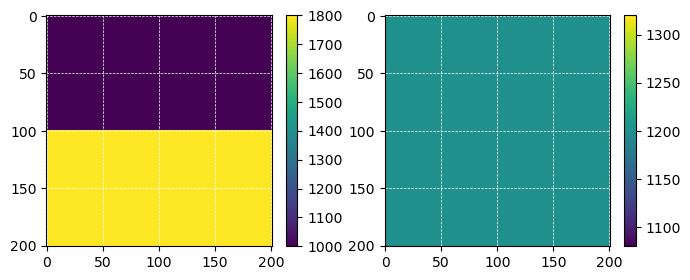

In [2]:
# True
!makevel nz=100 nx=$nx v000=1000 > c1
!makevel nz=101 nx=$nx v000=1800 > c2
!cat c1 c2 > tmp && transp < tmp n1=$nx > true
!rm c1 c2 tmp

!makevel nz=1   nx=$nx v000=100  > topo

# Background
!makevel nz=$nz nx=$nx v000=1200 > init

#plot
plt.figure(figsize=(8,3))
true=read('true'); init=read('init')
plt.subplot(1,2,1); imshow(true)
plt.subplot(1,2,2); imshow(init)

In [3]:
!cat setup_default

MODEL_SIZE              '201 201 1'
MODEL_SPACING           '10 10 1'
FILE_MODEL              true
MODEL_ATTRIBUTES        vp #'vp rho'
FILE_TOPO               'topo'

IS_FREESURFACE          F

ACQUI_GEOMETRY          spread
FS                      '40 500 500'
FR                      '40 10  0'
DR                      '0  20 0'
NR                      100

SCOMP                   vz
RCOMP                   vz #'p vz'

WAVELET_TYPE            ricker
#T0                      0.5
#FILE_WAVELET            'fricker_dt6000.su'

IF_HICKS        F
IF_BLOOM        F

IF_USE_RANDOM   F

NT           2000
DT           0.002
FPEAK        7

## for PFEI ##
FILE_DATA_PREFIX    'results_obs/Ru_Shot'
WEIGHTING           'none'

PARAMETER           'vp:1000:1800'

SMOOTHING     'none'
#PRECO         'z^0'


#DESCENT_DIR     'random'  #'-curr%pg'

#LS_SCALING  'none'


#SNAPSHOT     vz
#NSNAPSHOT    50

IF_USE_CHECKPOINT   F
RCOMP       px


In [4]:
vp=init
vs=vp/np.sqrt(3)
rho=1000.
def gvp(glda):     return  glda            *2*rho*vp
def gvs(glda,gmu): return (glda*(-2) + gmu)*2*rho*vs

## PSV2ndord

### uz-uz

#### Obs & Syn data

In [5]:
!cp setup_default setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP uz' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "SNAPSHOT  'uz ux'" >> setup
!echo "DIR_OUT     results_obs" >> setup

run(app='../../exe/fwd_PSV2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 643320 Sep  9 15:30 ../../exe/fwd_PSV2nd_FDSG_O4_
 Git Commit: 5b7e433
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/10/2025
System time: 08:27:53
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.5*Vmax/dx
Requir

In [6]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP uz' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "DIR_OUT     results_syn" >> setup

run(app='../../exe/fwd_PSV2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 643320 Sep  9 15:30 ../../exe/fwd_PSV2nd_FDSG_O4_
 Git Commit: 5b7e433
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/10/2025
System time: 08:27:56
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_syn
 Output directory:results_syn/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.5*Vmax/dx
Requir

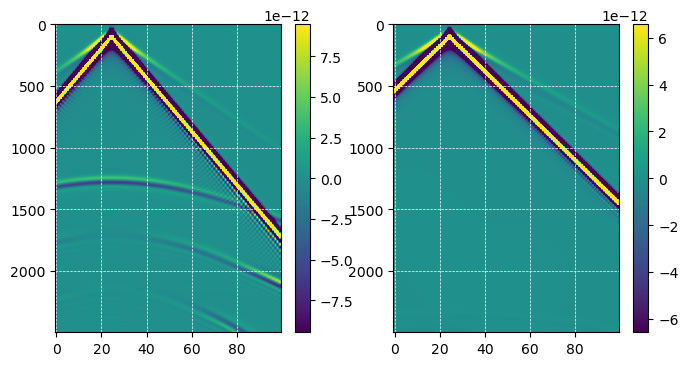

In [7]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=95)
plt.subplot(1,2,2); imshow(read_su('results_syn/Ru_Shot0001.su'),perc=95)

#### Gradient

In [5]:
!cp setup_default setup
!echo "DIR_OUT     resref" >> setup
!echo 'FILE_MODEL  init' >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP uz' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "SNAPSHOT  'uz ux'" >> setup

!echo "ALPHAS      1 " >> setup
run(app='../../exe/gradienttest_PSV2nd_FDSG_O4_velocities-density')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 906216 Sep 10 08:41 ../../exe/gradienttest_PSV2nd_FDSG_O4_velocities-density
 Git Commit: 3b2f322
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/12/2025
System time: 16:51:54
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI       
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : resref
 Output directory:resref/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   

 it----        1500
 fld_a minmax values:  -3.72554716E-20   8.79604993E-20
 fld_u minmax values:  -2.70666475E-11   3.79785196E-11
 it----        1000
 fld_a minmax values:  -1.64960183E-19   9.68140655E-20
 fld_u minmax values:  -2.73363103E-11   5.02843531E-11
 it----         500
 fld_a minmax values:  -3.32107794E-19   1.76494028E-19
 fld_u minmax values:  -6.20786964E-11   8.25637336E-11
 Elapsed time to evolve field           2.20823288E-03
 Elapsed time to load boundary          2.46872902E-02
 Elapsed time to update field           1.32835102    
 Elapsed time to rm source              3.85856628E-03
 Elapsed time -----------------------
 Elapsed time to add adj & virtual src       1.46574974E-02
 Elapsed time to update adj field            1.33008766    
 Elapsed time to evolve adj field            4.27436829E-03
 Elapsed time to extract fields              0.00000000    
 Elapsed time to compute Poynting vectors    0.00000000    
 Elapsed time to correlate                   1

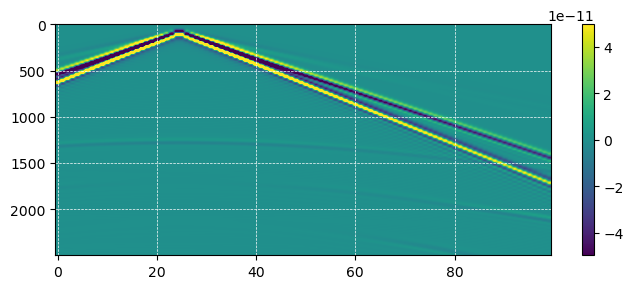

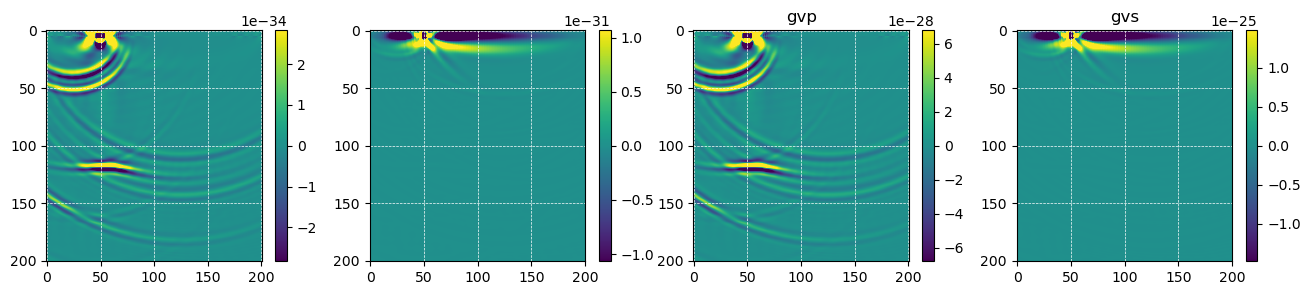

In [18]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

# plt.figure(figsize=(8,3))
# plt.subplot(1,2,1); imshow(read('results/a_star_u%glda'),title='glda',perc=98)
# plt.subplot(1,2,2); imshow(read('results/a_star_u%gmu' ),title='gmu' ,perc=98)

corr=read('results/correlate_gradient',n=(3*nx,nz))
glda=corr[:,  nx:2*nx]
gmu =corr[:,2*nx:]

plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(glda,perc=98)
plt.subplot(1,4,2); imshow(gmu ,perc=98)
plt.subplot(1,4,3); imshow(gvp(glda),title='gvp',perc=98)
plt.subplot(1,4,4); imshow(gvs(glda,gmu),title='gvs',perc=98)

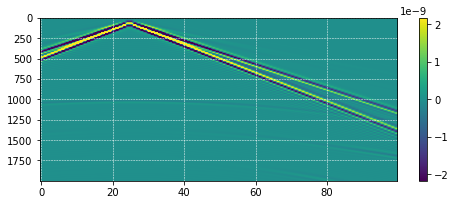

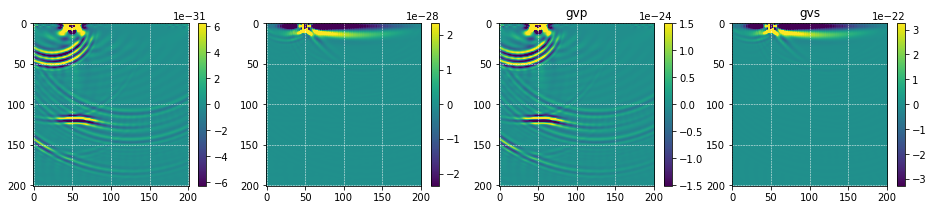

In [9]:
# ## OLD fig using m_propagator_DAS
# plt.figure(figsize=(8,3))
# imshow(read_su('results/dadj_Shot0001.su'),perc=98)

# # plt.figure(figsize=(8,3))
# # plt.subplot(1,2,1); imshow(read('results/a_star_u%glda'),title='glda',perc=98)
# # plt.subplot(1,2,2); imshow(read('results/a_star_u%gmu' ),title='gmu' ,perc=98)

# corr=read('results/correlate_gradient',n=(3*nx,nz))
# glda=corr[:,  nx:2*nx]
# gmu =corr[:,2*nx:]

# plt.figure(figsize=(16,3))
# plt.subplot(1,4,1); imshow(glda,perc=98)
# plt.subplot(1,4,2); imshow(gmu ,perc=98)
# plt.subplot(1,4,3); imshow(gvp(glda),title='gvp',perc=98)
# plt.subplot(1,4,4); imshow(gvs(glda,gmu),title='gvs',perc=98)

#### gradienttest on gvp

In [21]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP uz' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond   9.99999975E-06   1231.60413       1231.60413       0.00000000     -0.339143217            -Infinity T
 1st cond   9.99999975E-05   1231.60437       1231.60413       2.44140625     -0.339143217     -0.138913065     F
 1st cond   1.00000005E-03   1231.60376       1231.60413     -0.366210908     -0.339143217      0.926087141     T
 1st cond   9.99999978E-03   1231.60083       1231.60413     -0.329589844     -0.339143217       1.02898562     T
 1st cond  0.100000001       1231.56946       1231.60413     -0.346679688     -0.339143217      0.978260994     T
 1st cond   1.00000000       1231.28149       1231.60413     -0.322631836     -0.339143217       1.05117714     T


In [19]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP uz' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup

!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   1231.60449       1231.60413      -36.6210938     -0.339143217       9.26087052E-03 F
 1st cond  -9.99999975E-05   1231.60413       1231.60413      -0.00000000     -0.339143217             Infinity T
 1st cond  -1.00000005E-03   1231.60461       1231.60413     -0.488281220     -0.339143217      0.694565356     F
 1st cond  -9.99999978E-03   1231.60620       1231.60413     -0.207519531     -0.339143217       1.63427126     F
 1st cond -0.100000001       1231.63721       1231.60413     -0.330810547     -0.339143217       1.02518868     F
 1st cond  -1.00000000       1231.95691       1231.60413     -0.352783203     -0.339143217      0.961336076     F


#### gradienttest on gvs

In [19]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP uz' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "PARAMETER    'vs:578:1039'" >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond   9.99999975E-06   70.1719360       70.1719589      -2.28881836      -5.44191170       2.37760758     T
 1st cond   9.99999975E-05   70.1714172       70.1719589      -5.41687012      -5.44191170       1.00462294     T
 1st cond   1.00000005E-03   70.1666489       70.1719589      -5.31005812      -5.44191170       1.02483094     T
 1st cond   9.99999978E-03   70.1190491       70.1719589      -5.29098511      -5.44191170       1.02852523     T
 1st cond  0.100000001       69.6503601       70.1719589      -5.21598816      -5.44191170       1.04331362     T
 1st cond   1.00000000       65.7289124       70.1719589      -4.44304657      -5.44191170       1.22481537     T


In [20]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP uz' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "PARAMETER    'vs:578:1039'" >> setup

!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   70.1720276       70.1719589      -6.86645508      -5.44191170      0.792535841     F
 1st cond  -9.99999975E-05   70.1725235       70.1719589      -5.64575195      -5.44191170      0.963894904     F
 1st cond  -1.00000005E-03   70.1773911       70.1719589      -5.43212843      -5.44191170       1.00180101     F
 1st cond  -9.99999978E-03   70.2244492       70.1719589      -5.24902344      -5.44191170       1.03674746     F
 1st cond -0.100000001       70.7028046       70.1719589      -5.30845642      -5.44191170       1.02514017     F
 1st cond  -1.00000000       75.1799316       70.1719589      -5.00797272      -5.44191170       1.08664966     F


### uz-ux

#### Obs & Syn data

In [22]:
!cp setup_default setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ux' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
#!echo "SNAPSHOT  'uz ux'" >> setup
!echo "DIR_OUT     results_obs" >> setup

run(app='../../exe/fwd_PSV2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 643320 Sep  9 15:30 ../../exe/fwd_PSV2nd_FDSG_O4_
 Git Commit: 5b7e433
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/10/2025
System time: 08:47:09
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_obs
 Output directory:results_obs/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.5*Vmax/dx
Requir

In [23]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ux' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
#!echo "SNAPSHOT  'uz ux'" >> setup
!echo "DIR_OUT     results_syn" >> setup

run(app='../../exe/fwd_PSV2nd_FDSG_O4_')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
-rwxrwxr-x 1 wzhou wzhou 643320 Sep  9 15:30 ../../exe/fwd_PSV2nd_FDSG_O4_
 Git Commit: 5b7e433
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/10/2025
System time: 08:47:17
System timezone: +03:00
                        
   WELCOME TO SeisJIMU FWD MODELING   
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT : results_syn
 Output directory:results_syn/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
CFL = Σ|coef| *Vmax *dt /rev_cell_diagonal
   -> dt ≤ 0.5*Vmax/dx
Requir

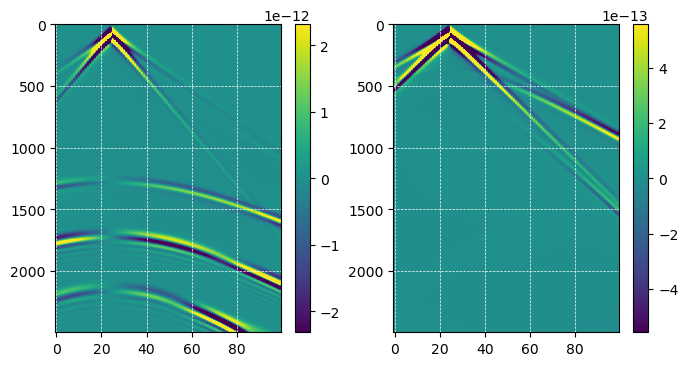

In [24]:
plt.figure(figsize=(8,4))
plt.subplot(1,2,1); imshow(read_su('results_obs/Ru_Shot0001.su'),perc=98)
plt.subplot(1,2,2); imshow(read_su('results_syn/Ru_Shot0001.su'),perc=98)

#### Gradient

In [25]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ux' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup

!echo "ALPHAS      1 " >> setup
run(app='../../exe/GradientTest')

 MPIWorld info:
  MPI_INIT_THREAD level:           0
  Number of MPI processors:           1
  Max number of OMP threads / processor:           4
 Working directory: (pwd)
/home/wzhou/Codes/GitHub/SeisJIMU/Demo/04_GradientTest
 Using executable: (ls -l $exe)
lrwxrwxrwx 1 wzhou wzhou 46 Sep 10 08:41 ../../exe/GradientTest -> gradienttest_PSV2nd_FDSG_O4_velocities-density
 Git Commit: 3b2f322
 Git Branch: PSV_2ndord
 Compiler: gfortran v13.3.0
 Version: 13.3.0
 Endianness:         1234
 System date: 09/10/2025
System time: 08:47:29
System timezone: +03:00
                        
       WELCOME TO SeisJIMU FWI       
 Setup file: setup
 DIR_IN is NOT found, take default: ./
 Input directory: ./
 DIR_OUT is NOT found, take default: ./results/
 Output directory:./results/
 Invoked field & propagator modules info : 
Time-domain ISOtropic 2D PSV (ELastic) propagation
2nd-order Displacement formulation
Vireux-Levandar Staggered-Grid Finite-Difference (FDSG) method
Cartesian O(x⁴,t²) stencil
C

 it----        1500
 fld_a minmax values:  -2.94809412E-21   2.55166700E-21
 fld_u minmax values:  -2.70666475E-11   3.79785196E-11
 it----        1000
 fld_a minmax values:  -2.76764091E-21   2.25658304E-21
 fld_u minmax values:  -2.73363103E-11   5.02843531E-11
 it----         500
 fld_a minmax values:  -2.43970399E-21   2.07156439E-21
 fld_u minmax values:  -6.20786964E-11   8.25637336E-11
 Elapsed time to evolve field           2.19678879E-03
 Elapsed time to load boundary          3.43127251E-02
 Elapsed time to update field           1.36612368    
 Elapsed time to rm source              5.50079346E-03
 Elapsed time -----------------------
 Elapsed time to add adj & virtual src       1.87416077E-02
 Elapsed time to update adj field            1.34360027    
 Elapsed time to evolve adj field            4.51231003E-03
 Elapsed time to extract fields              0.00000000    
 Elapsed time to compute Poynting vectors    0.00000000    
 Elapsed time to correlate                   1

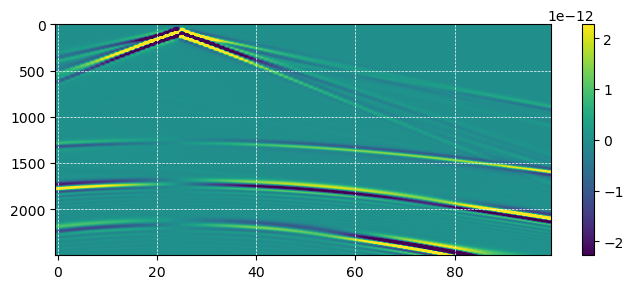

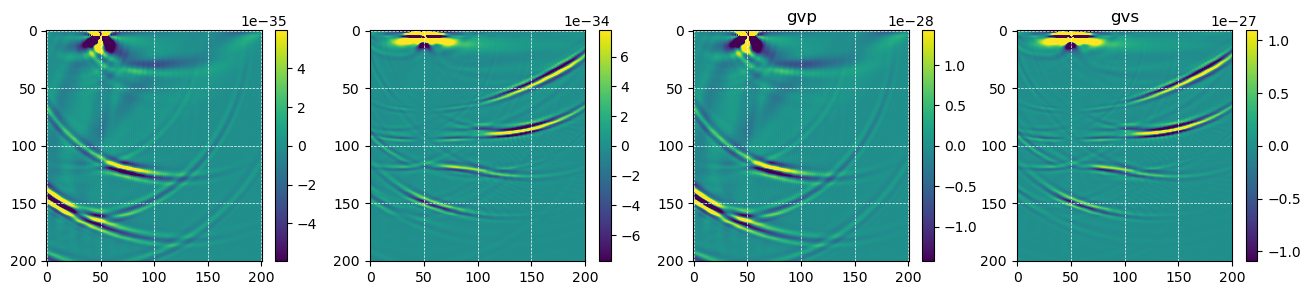

In [26]:
plt.figure(figsize=(8,3))
imshow(read_su('results/dadj_Shot0001.su'),perc=98)

corr=read('results/correlate_gradient',n=(3*nx,nz))
glda=corr[:,  nx:2*nx]
gmu =corr[:,2*nx:]

plt.figure(figsize=(16,3))
plt.subplot(1,4,1); imshow(glda,perc=98)
plt.subplot(1,4,2); imshow(gmu ,perc=98)
plt.subplot(1,4,3); imshow(gvp(glda),title='gvp',perc=98)
plt.subplot(1,4,4); imshow(gvs(glda,gmu),title='gvs',perc=98)

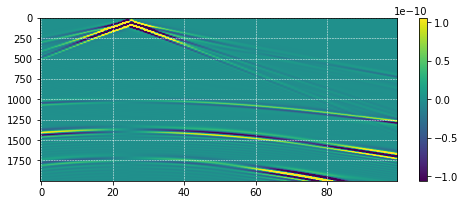

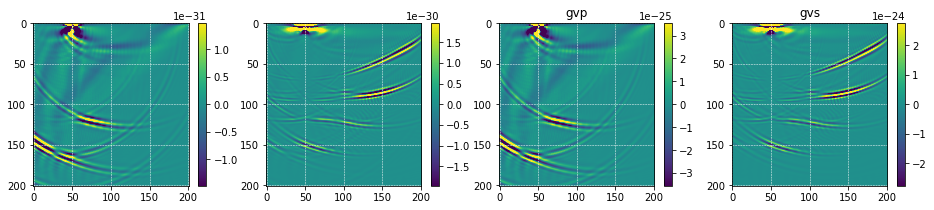

In [18]:
# ## OLD fig using m_propagator_DAS

# plt.figure(figsize=(8,3))
# imshow(read_su('results/dadj_Shot0001.su'),perc=98)

# corr=read('results/correlate_gradient',n=(3*nx,nz))
# glda=corr[:,  nx:2*nx]
# gmu =corr[:,2*nx:]

# plt.figure(figsize=(16,3))
# plt.subplot(1,4,1); imshow(glda,perc=98)
# plt.subplot(1,4,2); imshow(gmu ,perc=98)
# plt.subplot(1,4,3); imshow(gvp(glda),title='gvp',perc=98)
# plt.subplot(1,4,4); imshow(gvs(glda,gmu),title='gvs',perc=98)

#### gradienttest on gvp

In [27]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ux' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond   9.99999975E-06   16.1071224       16.1071072       1.52587891     -0.435990006     -0.285730422     F
 1st cond   9.99999975E-05   16.1070957       16.1071072     -0.114440918     -0.435990006       3.80973887     T
 1st cond   1.00000005E-03   16.1066990       16.1071072     -0.408172578     -0.435990006       1.06815112     T
 1st cond   9.99999978E-03   16.1029377       16.1071072     -0.416946411     -0.435990006       1.04567397     T
 1st cond  0.100000001       16.0648708       16.1071072     -0.422363281     -0.435990006       1.03226304     T
 1st cond   1.00000000       15.7123575       16.1071072     -0.394749641     -0.435990006       1.10447216     T


In [28]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ux' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup

!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   16.1071377       16.1071072      -3.05175781     -0.435990006      0.142865211     F
 1st cond  -9.99999975E-05   16.1071758       16.1071072     -0.686645508     -0.435990006      0.634956479     F
 1st cond  -1.00000005E-03   16.1075497       16.1071072     -0.442504853     -0.435990006      0.985277355     F
 1st cond  -9.99999978E-03   16.1112003       16.1071072     -0.409317017     -0.435990006       1.06516457     F
 1st cond -0.100000001       16.1484947       16.1071072     -0.413875580     -0.435990006       1.05343258     F
 1st cond  -1.00000000       16.5453701       16.1071072     -0.438262939     -0.435990006      0.994813740     F


#### gradienttest on gvs

In [28]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ux' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "PARAMETER   'vs:578:1039'" >> setup

!echo "ALPHAS '1e-5 1e-4 1e-3 1e-2 1e-1 1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond   9.99999975E-06   8.35624218       8.35624218       0.00000000      -1.07587481            -Infinity T
 1st cond   9.99999975E-05   8.35615158       8.35624218     -0.905990601      -1.07587481       1.18751216     T
 1st cond   1.00000005E-03   8.35523033       8.35624218      -1.01184845      -1.07587481       1.06327665     T
 1st cond   9.99999978E-03   8.34577084       8.35624218      -1.04713440      -1.07587481       1.02744675     T
 1st cond  0.100000001       8.25375557       8.35624218      -1.02486610      -1.07587481       1.04977107     T
 1st cond   1.00000000       7.58836699       8.35624218     -0.767875195      -1.07587481       1.40110636     T


In [29]:
!cp setup_default setup
!echo 'FILE_MODEL  init' >> setup
!echo 'DT   0.0016' >> setup; echo 'NT   2500' >> setup
!echo 'SCOMP uz' >> setup
!echo 'RCOMP ux' >> setup; echo 'IF_MUST_USE_RCOMP   T' >> setup
!echo "PARAMETER   'vs:578:1039'" >> setup
!echo "ALPHAS '-1e-5 -1e-4 -1e-3 -1e-2 -1e-1 -1' " >> setup

!rm -r results
run(app='../../exe/GradientTest',out='out')

!echo '            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond'
!grep '1st cond' out

            alpha            pert%f           curr%f    (pert%f-curr%f)/alpha    curr%g_dot_d    if_1st_cond
 1st cond  -9.99999975E-06   8.35625648       8.35624218      -1.43051147      -1.07587481      0.752090991     F
 1st cond  -9.99999975E-05   8.35636044       8.35624218      -1.18255615      -1.07587481      0.909787476     F
 1st cond  -1.00000005E-03   8.35729599       8.35624218      -1.05381012      -1.07587481       1.02093804     F
 1st cond  -9.99999978E-03   8.36681652       8.35624218      -1.05743408      -1.07587481       1.01743913     F
 1st cond -0.100000001       8.46435928       8.35624218      -1.08117104      -1.07587481      0.995101392     F
 1st cond  -1.00000000       9.68546200       8.35624218      -1.32921982      -1.07587481      0.809403241     F
